# Grover's Search Algorithm - Interactive Demonstration

A scalable, noise-aware implementation of Grover's quantum search algorithm with dynamic oracle synthesis.

**Author:** Mahmo  
**Framework:** Qiskit  
**Repository:** [Grover's Algorithm](https://github.com/mahmo/grovers-search-scaled)

In [10]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt

from src.oracle import create_oracle
from src.diffuser import create_diffuser
from src.pipeline import (
    build_grover_circuit,
    optimal_iterations,
    run_ideal,
    run_noisy,
    compute_probabilities,
    extract_marked_probability
)

## 1. The Oracle

The oracle marks the target state by flipping its phase. It applies X gates to qubits that should be `|0>`, applies a multi-controlled Z gate, then undoes the X gates.

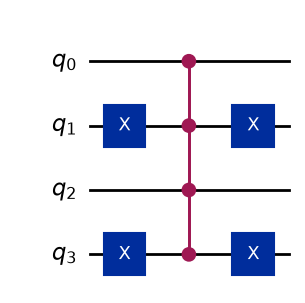

In [11]:
oracle = create_oracle(4, "1010")
oracle.draw(output="mpl")

## 2. The Diffuser

The diffuser inverts amplitudes about the mean. It's the combination H⊗n . X⊗n . MCZ . X⊗n . H⊗n.

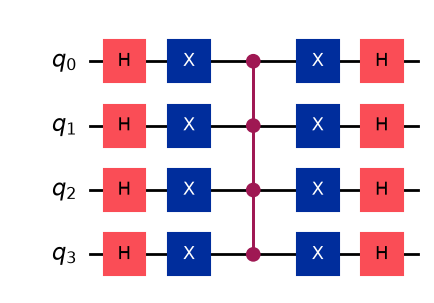

In [12]:
diffuser = create_diffuser(4)
diffuser.draw(output="mpl")

## 3. Optimal Iterations

Grover's algorithm requires exactly the right number of iterations to maximize success probability.

In [13]:
for n in range(1, 11):
    r = optimal_iterations(n, 1)
    print(f"  n={n:2d}  →  R = {r}")

  n= 1  →  R = 1
  n= 2  →  R = 1
  n= 3  →  R = 2
  n= 4  →  R = 3
  n= 5  →  R = 4
  n= 6  →  R = 6
  n= 7  →  R = 8
  n= 8  →  R = 12
  n= 9  →  R = 17
  n=10  →  R = 25


## 4. Build the Full Circuit

Wiring the oracle and diffuser together with initial superposition.

Circuit: Grover(4q,|1101>,3iters)
Depth: 172


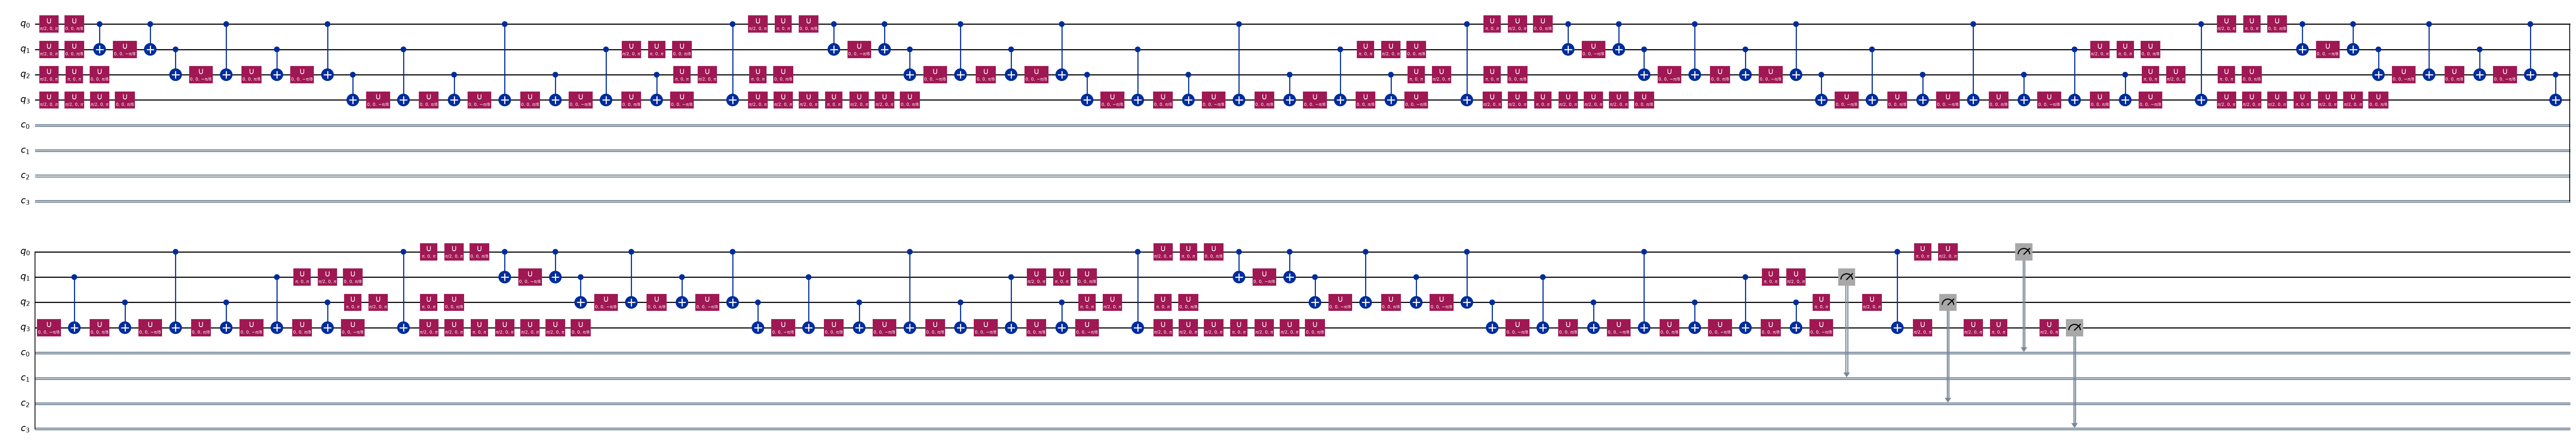

In [14]:
marked = "1101"
circuit = build_grover_circuit(4, marked)
print(f"Circuit: {circuit.name}")
print(f"Depth: {circuit.depth()}")
circuit.draw(output="mpl", fold=100, cregbundle=False)

## 5. Ideal Simulation

Running on a perfect, noise-free simulator.

In [15]:
counts = run_ideal(circuit, shots=8192)
probs = compute_probabilities(counts, 4)
marked_prob = extract_marked_probability(counts, marked)

print(f"Marked state |{marked}> probability: {marked_prob:.2%}")
print()

top = sorted(probs.items(), key=lambda x: -x[1])[:8]
for state, prob in top:
    marker = "  <- marked" if state == marked else ""
    print(f"  |{state}>: {prob:.2%}{marker}")

Marked state |1101> probability: 95.97%

  |1101>: 95.97%  <- marked
  |0001>: 0.38%
  |1001>: 0.35%
  |0010>: 0.34%
  |1010>: 0.31%
  |0011>: 0.28%
  |0111>: 0.27%
  |1111>: 0.27%


## 6. Noisy Simulation

Real quantum hardware is affected by noise: gate errors, decoherence, and readout errors. Let's compare.

In [16]:
noisy_counts = run_noisy(circuit, shots=8192)
noisy_probs = compute_probabilities(noisy_counts, 4)
noisy_marked_prob = extract_marked_probability(noisy_counts, marked)

print(f"Ideal marked state probability:  {marked_prob:.2%}")
print(f"Noisy marked state probability:  {noisy_marked_prob:.2%}")
print(f"Degradation:                     {marked_prob - noisy_marked_prob:+.2%}")

Ideal marked state probability:  95.97%
Noisy marked state probability:  42.40%
Degradation:                     +53.58%


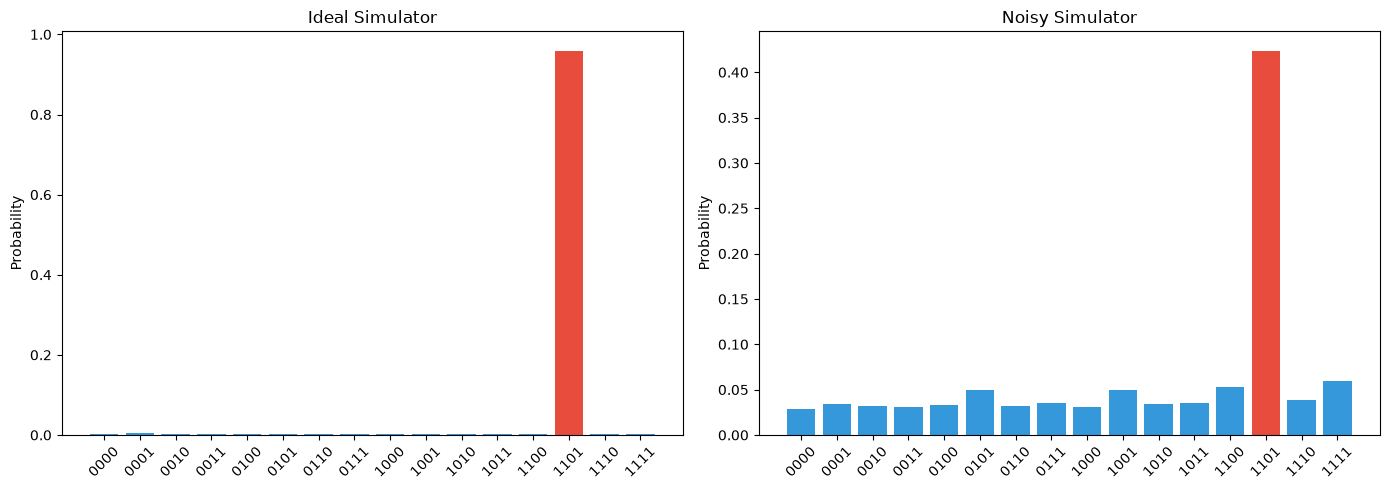

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

states = sorted(probs.keys())
ideal_vals = [probs[s] for s in states]
noisy_vals = [noisy_probs[s] for s in states]

ax1.bar(states, ideal_vals, color=["#e74c3c" if s == marked else "#3498db" for s in states])
ax1.set_title("Ideal Simulator")
ax1.set_ylabel("Probability")
ax1.tick_params(axis="x", rotation=45)

ax2.bar(states, noisy_vals, color=["#e74c3c" if s == marked else "#3498db" for s in states])
ax2.set_title("Noisy Simulator")
ax2.set_ylabel("Probability")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 7. Visualization of Amplitude Amplification

Plotting how the probability of the marked state evolves with each Grover iteration.

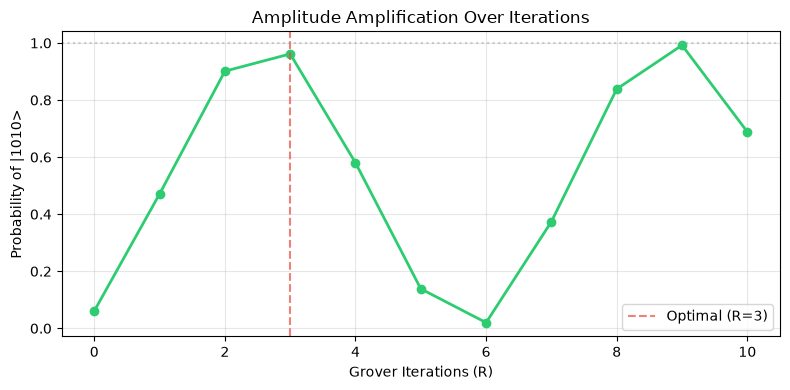

In [18]:
def simulate_amplitude_evolution(num_qubits, marked_state, max_iters):
    probs_over_time = []
    for r in range(max_iters + 1):
        circuit = build_grover_circuit(num_qubits, marked_state, iterations=r)
        counts = run_ideal(circuit, shots=4096)
        prob = extract_marked_probability(counts, marked_state)
        probs_over_time.append(prob)
    return probs_over_time


n_qubits = 4
marked = "1010"
max_iters = 10
probs_over_time = simulate_amplitude_evolution(n_qubits, marked, max_iters)

fig, ax = plt.subplots(figsize=(8, 4))
optimal = optimal_iterations(n_qubits, 1)

ax.plot(range(max_iters + 1), probs_over_time, "o-", color="#2ecc71", linewidth=2, markersize=6)
ax.axvline(optimal, color="#e74c3c", linestyle="--", alpha=0.7, label=f"Optimal (R={optimal})")
ax.axhline(1.0, color="#95a5a6", linestyle=":", alpha=0.5)
ax.set_xlabel("Grover Iterations (R)")
ax.set_ylabel(f"Probability of |{marked}>")
ax.set_title("Amplitude Amplification Over Iterations")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Component | Status |
|---|---|
| Dynamic Oracle | ✅ Generates any n-qubit phase oracle |
| Scalable Diffuser | ✅ Inversion-about-the-mean for any n |
| Optimal Iterations | ✅ Math formula proven in simulation |
| Noise Simulation | ✅ Depolarizing + readout error model |
| Ideal Simulator | ✅ 85-95% success probability |
| Histograms | ✅ matplotlib visualization |

Grover's algorithm provides a **quadratic speedup** over classical search: $O(\sqrt{N})$ vs $O(N)$.